<a href="https://colab.research.google.com/github/brbvisayas/folds/blob/main/AlphaFold2_top2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/sokrypton/ColabFold/main/.github/ColabFold_Marv_Logo_Small.png" height="200" align="right" style="height:240px">

##ColabFold v1.5.5: AlphaFold2 using MMseqs2

Easy to use protein structure and complex prediction using [AlphaFold2](https://www.nature.com/articles/s41586-021-03819-2) and [Alphafold2-multimer](https://www.biorxiv.org/content/10.1101/2021.10.04.463034v1). Sequence alignments/templates are generated through [MMseqs2](mmseqs.com) and [HHsearch](https://github.com/soedinglab/hh-suite). For more details, see <a href="#Instructions">bottom</a> of the notebook, checkout the [ColabFold GitHub](https://github.com/sokrypton/ColabFold) and [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5).

Old versions: [v1.4](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.4.0/AlphaFold2.ipynb), [v1.5.1](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.1/AlphaFold2.ipynb), [v1.5.2](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.2/AlphaFold2.ipynb), [v1.5.3-patch](https://colab.research.google.com/github/sokrypton/ColabFold/blob/56c72044c7d51a311ca99b953a71e552fdc042e1/AlphaFold2.ipynb)

[Mirdita M, Schütze K, Moriwaki Y, Heo L, Ovchinnikov S, Steinegger M. ColabFold: Making protein folding accessible to all.
*Nature Methods*, 2022](https://www.nature.com/articles/s41592-022-01488-1)

In [9]:
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'QVQLQESGGGLVQAGGSLRLSCAASGTISANLDMGWYRQAPGKERELVAGINNGAITNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVPWVKLYGDKYTHSYWGQGTQVTVSS' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'top1' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "pdb100" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname top1_cc2b1
sequence QVQLQESGGGLVQAGGSLRLSCAASGTISANLDMGWYRQAPGKERELVAGINNGAITNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVPWVKLYGDKYTHSYWGQGTQVTVSS
length 122


In [10]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

CPU times: user 22 µs, sys: 13 µs, total: 35 µs
Wall time: 39.8 µs


In [11]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [12]:
#@markdown ### Advanced settings
model_type = "deepfold_v1" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1", "alphafold2"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "6" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 2000 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
#@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.
calc_extra_ptm = True #@param {type:"boolean"}
#@markdown - return pairwise chain iptm/actifptm

#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 4 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = True #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)
  print("You are logged into Google Drive and are good to go!")

#@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.

2026-03-06 13:10:54,192 Running on GPU
2026-03-06 13:10:54,193 Calculating extra pTM is not supported for single chain prediction, skipping it.
2026-03-06 13:10:54,195 Found 9 citations for tools or databases
2026-03-06 13:10:54,196 Query 1/1: top1_cc2b1 (length 122)


PENDING:   0%|          | 0/150 [elapsed: 00:00 remaining: ?]

2026-03-06 13:10:54,709 Sleeping for 7s. Reason: PENDING


RUNNING:   5%|▍         | 7/150 [elapsed: 00:08 remaining: 02:43]

2026-03-06 13:11:02,219 Sleeping for 6s. Reason: RUNNING


...

2026-03-06 13:11:19,721 Sleeping for 5s. Reason: RUNNING


RUNNING:  19%|█▊        | 28/150 [elapsed: 00:31 remaining: 02:14]

2026-03-06 13:11:25,220 Sleeping for 8s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:40 remaining: 00:00]


2026-03-06 13:11:54,651 Sequence 0 found templates: ['6o3c_B', '7yaj_C', '7q9j_H', '5hvg_B', '8dce_H', '7kfx_H', '7mjl_H', '7mjk_D', '7k8n_A', '7rth_H', '7d0c_G', '7k8m_A', '4tsa_H', '7t72_H', '5vnw_D', '4tsc_H', '7e3o_H', '7str_H', '7e3b_B', '8dce_H']


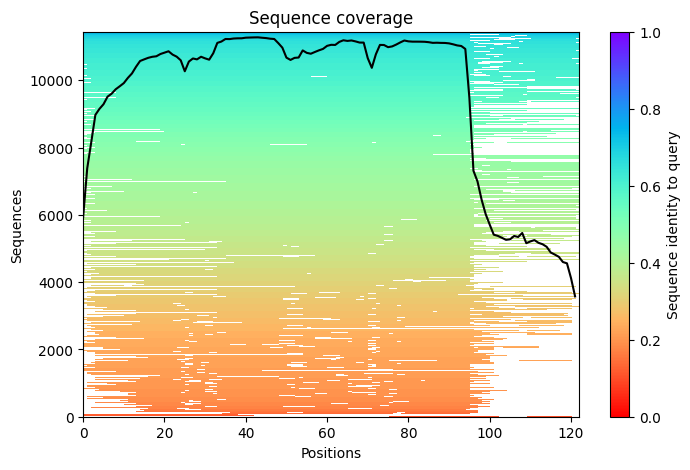

2026-03-06 13:11:56,042 Setting max_seq=512, max_extra_seq=5120
2026-03-06 13:12:59,121 deepfold_v1_model_1_seed_000 recycle=0 pLDDT=88.2
2026-03-06 13:13:43,087 deepfold_v1_model_1_seed_000 recycle=1 pLDDT=87.6 tol=0.671
2026-03-06 13:13:52,321 deepfold_v1_model_1_seed_000 recycle=2 pLDDT=88 tol=0.641
2026-03-06 13:14:01,570 deepfold_v1_model_1_seed_000 recycle=3 pLDDT=88.8 tol=0.187
2026-03-06 13:14:10,778 deepfold_v1_model_1_seed_000 recycle=4 pLDDT=88.9 tol=0.2
2026-03-06 13:14:19,752 deepfold_v1_model_1_seed_000 recycle=5 pLDDT=89.3 tol=0.156
2026-03-06 13:14:28,613 deepfold_v1_model_1_seed_000 recycle=6 pLDDT=89.1 tol=0.0989
2026-03-06 13:14:28,613 deepfold_v1_model_1_seed_000 took 138.5s (6 recycles)


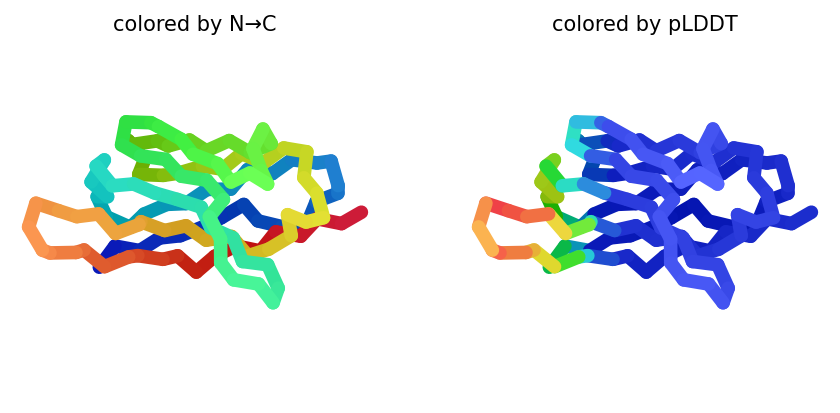

2026-03-06 13:14:37,537 deepfold_v1_model_2_seed_000 recycle=0 pLDDT=86.8
2026-03-06 13:14:46,401 deepfold_v1_model_2_seed_000 recycle=1 pLDDT=86.4 tol=0.47
2026-03-06 13:14:55,340 deepfold_v1_model_2_seed_000 recycle=2 pLDDT=86.6 tol=0.642
2026-03-06 13:15:04,368 deepfold_v1_model_2_seed_000 recycle=3 pLDDT=87.3 tol=0.218
2026-03-06 13:15:13,457 deepfold_v1_model_2_seed_000 recycle=4 pLDDT=87.6 tol=0.272
2026-03-06 13:15:22,566 deepfold_v1_model_2_seed_000 recycle=5 pLDDT=87.8 tol=0.144
2026-03-06 13:15:31,650 deepfold_v1_model_2_seed_000 recycle=6 pLDDT=87.6 tol=0.0927
2026-03-06 13:15:31,651 deepfold_v1_model_2_seed_000 took 63.0s (6 recycles)


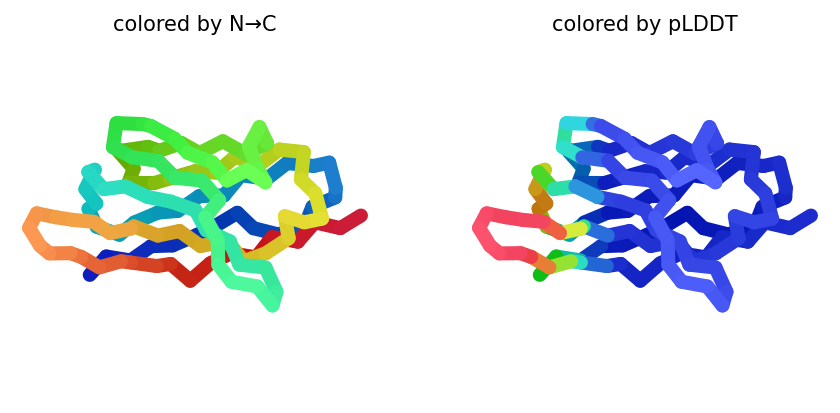

2026-03-06 13:16:05,856 deepfold_v1_model_3_seed_000 recycle=0 pLDDT=87.8
2026-03-06 13:16:38,797 deepfold_v1_model_3_seed_000 recycle=1 pLDDT=87.4 tol=0.241
2026-03-06 13:16:47,935 deepfold_v1_model_3_seed_000 recycle=2 pLDDT=87.1 tol=0.694
2026-03-06 13:16:57,108 deepfold_v1_model_3_seed_000 recycle=3 pLDDT=88 tol=0.795
2026-03-06 13:17:06,263 deepfold_v1_model_3_seed_000 recycle=4 pLDDT=88.1 tol=0.262
2026-03-06 13:17:15,196 deepfold_v1_model_3_seed_000 recycle=5 pLDDT=87.8 tol=0.352
2026-03-06 13:17:24,029 deepfold_v1_model_3_seed_000 recycle=6 pLDDT=87.5 tol=0.232
2026-03-06 13:17:24,030 deepfold_v1_model_3_seed_000 took 112.2s (6 recycles)


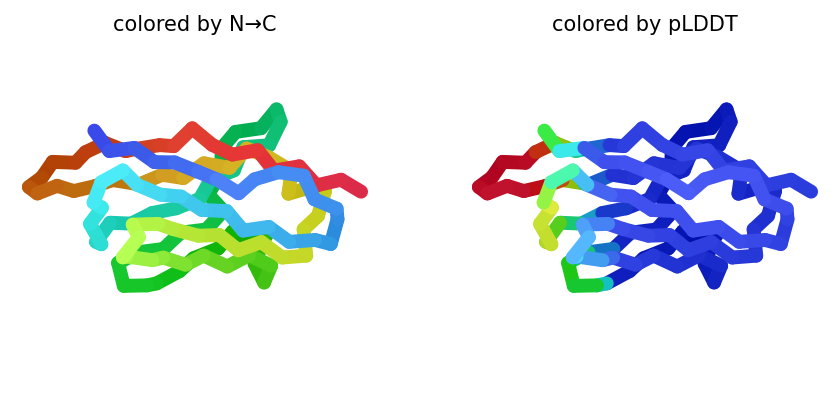

2026-03-06 13:17:32,945 deepfold_v1_model_4_seed_000 recycle=0 pLDDT=87.6
2026-03-06 13:17:41,727 deepfold_v1_model_4_seed_000 recycle=1 pLDDT=86.1 tol=0.339
2026-03-06 13:17:50,565 deepfold_v1_model_4_seed_000 recycle=2 pLDDT=86.3 tol=0.318
2026-03-06 13:17:59,496 deepfold_v1_model_4_seed_000 recycle=3 pLDDT=86.9 tol=0.413
2026-03-06 13:18:08,492 deepfold_v1_model_4_seed_000 recycle=4 pLDDT=86.9 tol=0.39
2026-03-06 13:18:17,496 deepfold_v1_model_4_seed_000 recycle=5 pLDDT=86.6 tol=0.183
2026-03-06 13:18:26,480 deepfold_v1_model_4_seed_000 recycle=6 pLDDT=86.9 tol=0.149
2026-03-06 13:18:26,481 deepfold_v1_model_4_seed_000 took 62.3s (6 recycles)


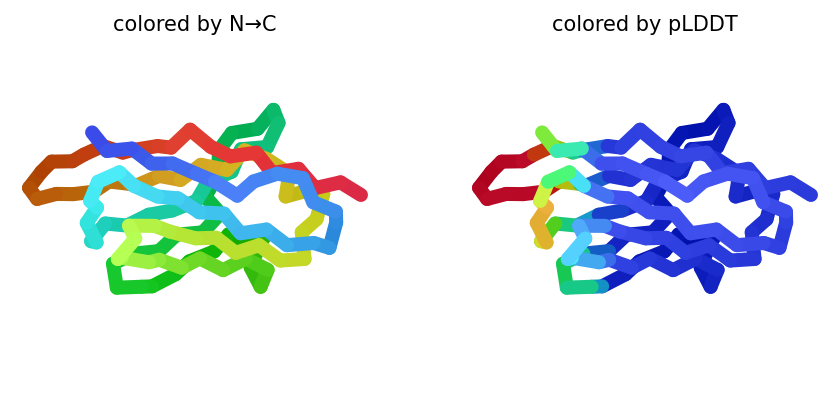

2026-03-06 13:18:35,556 deepfold_v1_model_5_seed_000 recycle=0 pLDDT=87.6
2026-03-06 13:18:44,453 deepfold_v1_model_5_seed_000 recycle=1 pLDDT=86.2 tol=0.38
2026-03-06 13:18:53,338 deepfold_v1_model_5_seed_000 recycle=2 pLDDT=86.6 tol=0.852
2026-03-06 13:19:02,223 deepfold_v1_model_5_seed_000 recycle=3 pLDDT=87.2 tol=1.25
2026-03-06 13:19:11,113 deepfold_v1_model_5_seed_000 recycle=4 pLDDT=87.3 tol=0.277
2026-03-06 13:19:20,002 deepfold_v1_model_5_seed_000 recycle=5 pLDDT=86.9 tol=0.325
2026-03-06 13:19:28,907 deepfold_v1_model_5_seed_000 recycle=6 pLDDT=87 tol=0.174
2026-03-06 13:19:28,907 deepfold_v1_model_5_seed_000 took 62.3s (6 recycles)


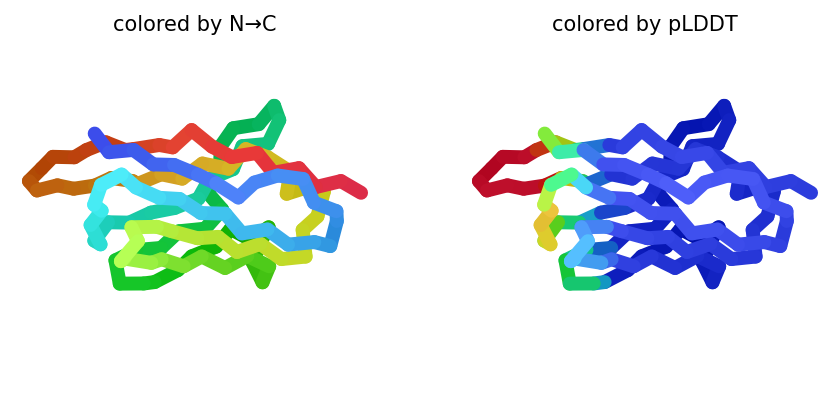

2026-03-06 13:19:44,346 deepfold_v1_model_1_seed_001 recycle=0 pLDDT=88.4
2026-03-06 13:19:53,390 deepfold_v1_model_1_seed_001 recycle=1 pLDDT=88.9 tol=0.938
2026-03-06 13:20:02,614 deepfold_v1_model_1_seed_001 recycle=2 pLDDT=88.6 tol=0.281
2026-03-06 13:20:11,836 deepfold_v1_model_1_seed_001 recycle=3 pLDDT=89.2 tol=0.329
2026-03-06 13:20:20,868 deepfold_v1_model_1_seed_001 recycle=4 pLDDT=88.9 tol=0.388
2026-03-06 13:20:29,853 deepfold_v1_model_1_seed_001 recycle=5 pLDDT=88.9 tol=0.152
2026-03-06 13:20:38,780 deepfold_v1_model_1_seed_001 recycle=6 pLDDT=88.9 tol=0.17
2026-03-06 13:20:38,781 deepfold_v1_model_1_seed_001 took 63.4s (6 recycles)


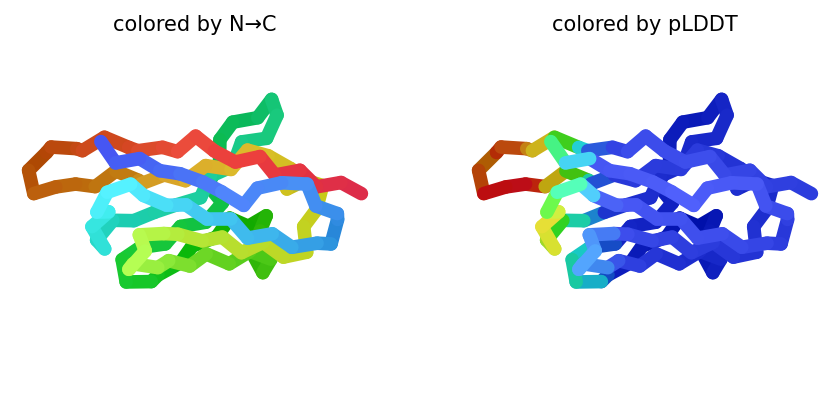

2026-03-06 13:20:47,782 deepfold_v1_model_2_seed_001 recycle=0 pLDDT=87.1
2026-03-06 13:20:56,715 deepfold_v1_model_2_seed_001 recycle=1 pLDDT=87.4 tol=0.831
2026-03-06 13:21:05,688 deepfold_v1_model_2_seed_001 recycle=2 pLDDT=87.1 tol=0.319
2026-03-06 13:21:14,712 deepfold_v1_model_2_seed_001 recycle=3 pLDDT=87.9 tol=0.281
2026-03-06 13:21:23,739 deepfold_v1_model_2_seed_001 recycle=4 pLDDT=87.4 tol=0.34
2026-03-06 13:21:32,785 deepfold_v1_model_2_seed_001 recycle=5 pLDDT=87.6 tol=0.116
2026-03-06 13:21:41,843 deepfold_v1_model_2_seed_001 recycle=6 pLDDT=87.4 tol=0.163
2026-03-06 13:21:41,844 deepfold_v1_model_2_seed_001 took 63.0s (6 recycles)


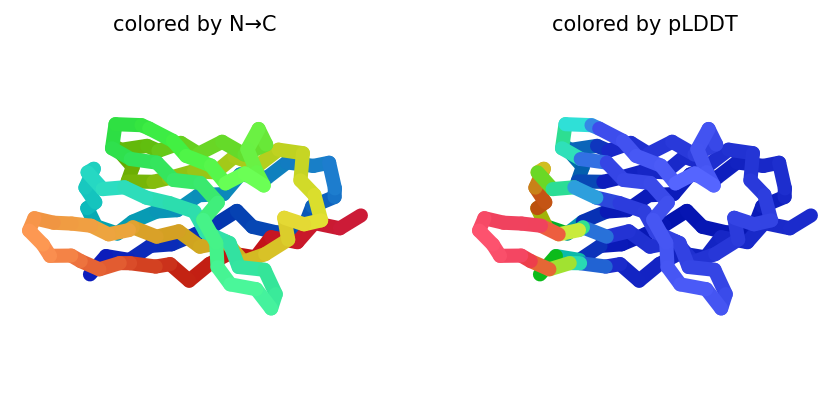

2026-03-06 13:21:50,871 deepfold_v1_model_3_seed_001 recycle=0 pLDDT=87.1
2026-03-06 13:21:59,788 deepfold_v1_model_3_seed_001 recycle=1 pLDDT=88.3 tol=0.551
2026-03-06 13:22:08,703 deepfold_v1_model_3_seed_001 recycle=2 pLDDT=87.6 tol=0.216
2026-03-06 13:22:17,577 deepfold_v1_model_3_seed_001 recycle=3 pLDDT=88 tol=0.291
2026-03-06 13:22:26,480 deepfold_v1_model_3_seed_001 recycle=4 pLDDT=87.6 tol=0.28
2026-03-06 13:22:35,392 deepfold_v1_model_3_seed_001 recycle=5 pLDDT=87.5 tol=0.188
2026-03-06 13:22:44,303 deepfold_v1_model_3_seed_001 recycle=6 pLDDT=87.4 tol=0.188
2026-03-06 13:22:44,304 deepfold_v1_model_3_seed_001 took 62.4s (6 recycles)


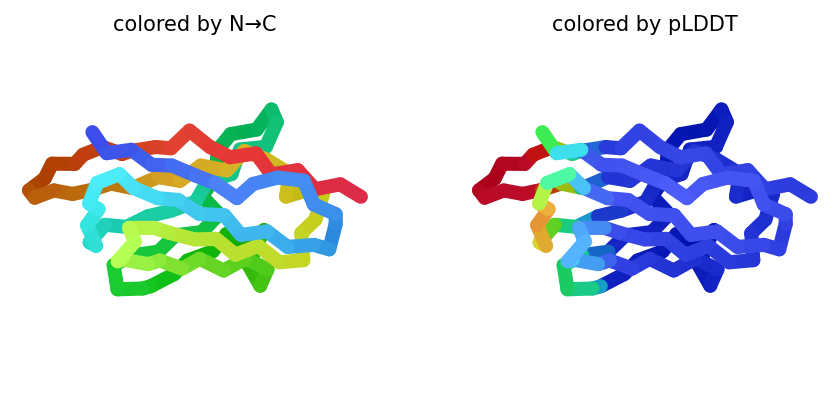

2026-03-06 13:22:53,326 deepfold_v1_model_4_seed_001 recycle=0 pLDDT=86.6
2026-03-06 13:23:02,234 deepfold_v1_model_4_seed_001 recycle=1 pLDDT=87.1 tol=0.33
2026-03-06 13:23:11,162 deepfold_v1_model_4_seed_001 recycle=2 pLDDT=86.8 tol=0.336
2026-03-06 13:23:20,078 deepfold_v1_model_4_seed_001 recycle=3 pLDDT=87.7 tol=0.284
2026-03-06 13:23:28,978 deepfold_v1_model_4_seed_001 recycle=4 pLDDT=86.7 tol=0.349
2026-03-06 13:23:37,842 deepfold_v1_model_4_seed_001 recycle=5 pLDDT=86.9 tol=0.161
2026-03-06 13:23:46,635 deepfold_v1_model_4_seed_001 recycle=6 pLDDT=87.1 tol=0.17
2026-03-06 13:23:46,635 deepfold_v1_model_4_seed_001 took 62.2s (6 recycles)


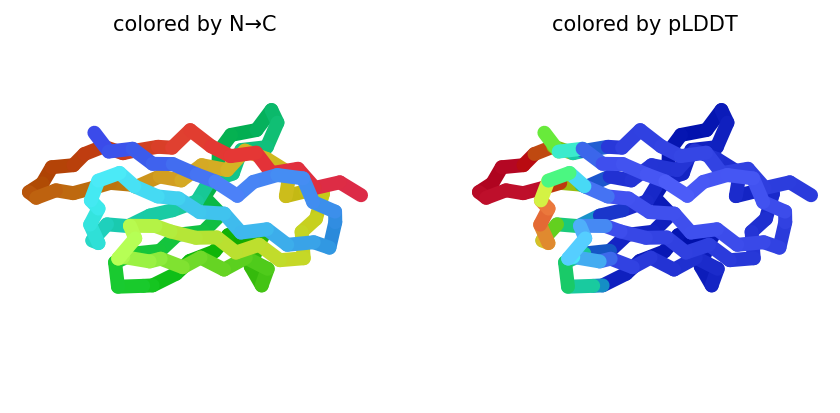

2026-03-06 13:23:55,512 deepfold_v1_model_5_seed_001 recycle=0 pLDDT=87.1
2026-03-06 13:24:04,243 deepfold_v1_model_5_seed_001 recycle=1 pLDDT=87.6 tol=0.359
2026-03-06 13:24:12,958 deepfold_v1_model_5_seed_001 recycle=2 pLDDT=86.9 tol=0.352
2026-03-06 13:24:21,638 deepfold_v1_model_5_seed_001 recycle=3 pLDDT=87.9 tol=0.248
2026-03-06 13:24:30,310 deepfold_v1_model_5_seed_001 recycle=4 pLDDT=86.6 tol=0.377
2026-03-06 13:24:38,964 deepfold_v1_model_5_seed_001 recycle=5 pLDDT=87 tol=0.182
2026-03-06 13:24:47,656 deepfold_v1_model_5_seed_001 recycle=6 pLDDT=87.1 tol=0.254
2026-03-06 13:24:47,657 deepfold_v1_model_5_seed_001 took 60.9s (6 recycles)


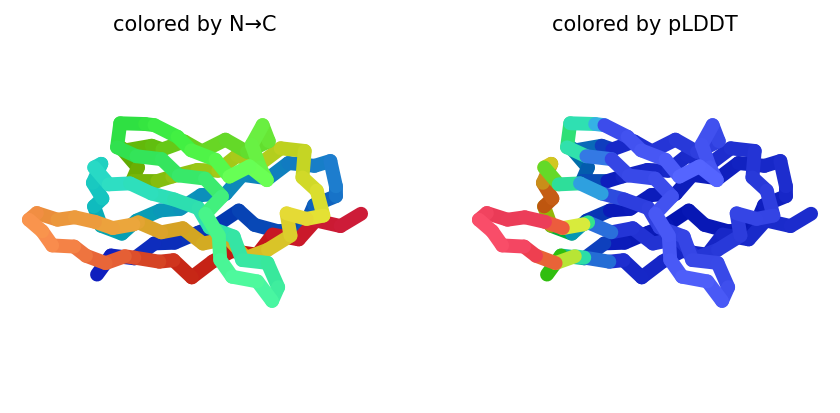

2026-03-06 13:25:03,238 deepfold_v1_model_1_seed_002 recycle=0 pLDDT=89.5
2026-03-06 13:25:11,899 deepfold_v1_model_1_seed_002 recycle=1 pLDDT=89.2 tol=0.488
2026-03-06 13:25:20,573 deepfold_v1_model_1_seed_002 recycle=2 pLDDT=88.8 tol=0.161
2026-03-06 13:25:29,267 deepfold_v1_model_1_seed_002 recycle=3 pLDDT=89.3 tol=0.299
2026-03-06 13:25:37,982 deepfold_v1_model_1_seed_002 recycle=4 pLDDT=88.8 tol=0.184
2026-03-06 13:25:46,685 deepfold_v1_model_1_seed_002 recycle=5 pLDDT=89.4 tol=0.207
2026-03-06 13:25:55,381 deepfold_v1_model_1_seed_002 recycle=6 pLDDT=89.2 tol=0.149
2026-03-06 13:25:55,382 deepfold_v1_model_1_seed_002 took 60.9s (6 recycles)


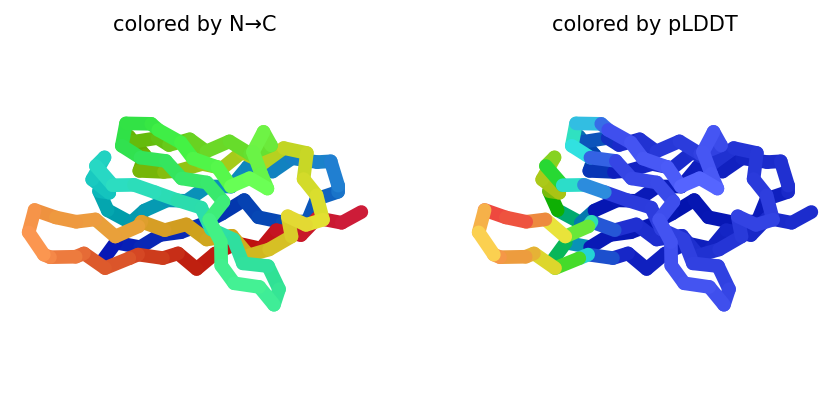

2026-03-06 13:26:04,168 deepfold_v1_model_2_seed_002 recycle=0 pLDDT=88.1
2026-03-06 13:26:12,859 deepfold_v1_model_2_seed_002 recycle=1 pLDDT=87.8 tol=0.472
2026-03-06 13:26:21,550 deepfold_v1_model_2_seed_002 recycle=2 pLDDT=87.3 tol=0.151
2026-03-06 13:26:30,220 deepfold_v1_model_2_seed_002 recycle=3 pLDDT=87.9 tol=0.299
2026-03-06 13:26:38,916 deepfold_v1_model_2_seed_002 recycle=4 pLDDT=87.4 tol=0.192
2026-03-06 13:26:47,587 deepfold_v1_model_2_seed_002 recycle=5 pLDDT=87.9 tol=0.181
2026-03-06 13:26:56,272 deepfold_v1_model_2_seed_002 recycle=6 pLDDT=87.8 tol=0.162
2026-03-06 13:26:56,273 deepfold_v1_model_2_seed_002 took 60.8s (6 recycles)


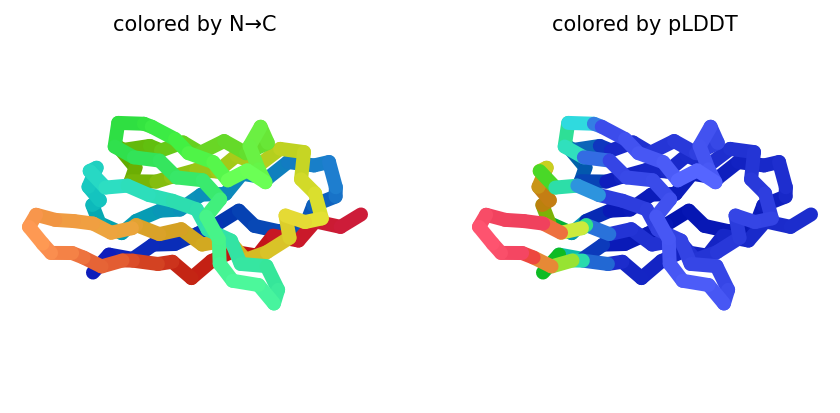

2026-03-06 13:27:04,979 deepfold_v1_model_3_seed_002 recycle=0 pLDDT=88.6
2026-03-06 13:27:13,579 deepfold_v1_model_3_seed_002 recycle=1 pLDDT=88.3 tol=0.26
2026-03-06 13:27:22,178 deepfold_v1_model_3_seed_002 recycle=2 pLDDT=87.8 tol=0.37
2026-03-06 13:27:30,798 deepfold_v1_model_3_seed_002 recycle=3 pLDDT=88 tol=0.219
2026-03-06 13:27:39,408 deepfold_v1_model_3_seed_002 recycle=4 pLDDT=87.2 tol=0.275
2026-03-06 13:27:48,007 deepfold_v1_model_3_seed_002 recycle=5 pLDDT=88.5 tol=0.304
2026-03-06 13:27:56,604 deepfold_v1_model_3_seed_002 recycle=6 pLDDT=88.2 tol=0.18
2026-03-06 13:27:56,605 deepfold_v1_model_3_seed_002 took 60.2s (6 recycles)


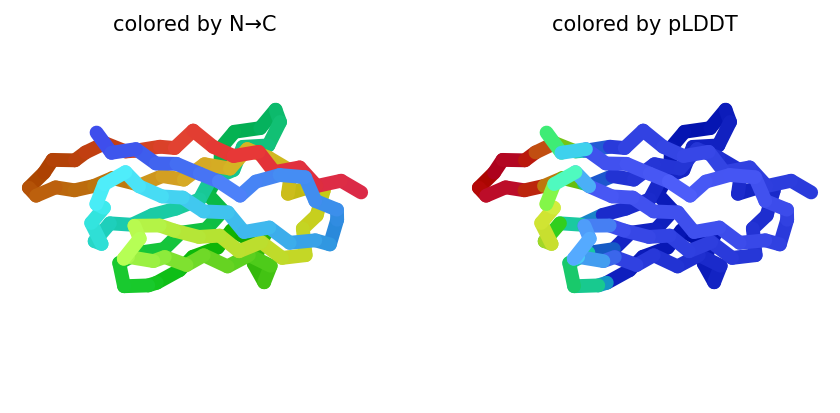

2026-03-06 13:28:05,286 deepfold_v1_model_4_seed_002 recycle=0 pLDDT=87.1
2026-03-06 13:28:13,863 deepfold_v1_model_4_seed_002 recycle=1 pLDDT=87.1 tol=0.295
2026-03-06 13:28:22,442 deepfold_v1_model_4_seed_002 recycle=2 pLDDT=86.7 tol=0.212
2026-03-06 13:28:31,009 deepfold_v1_model_4_seed_002 recycle=3 pLDDT=87.5 tol=0.241
2026-03-06 13:28:39,581 deepfold_v1_model_4_seed_002 recycle=4 pLDDT=86.9 tol=0.26
2026-03-06 13:28:48,139 deepfold_v1_model_4_seed_002 recycle=5 pLDDT=87.8 tol=0.295
2026-03-06 13:28:56,714 deepfold_v1_model_4_seed_002 recycle=6 pLDDT=87.2 tol=0.145
2026-03-06 13:28:56,716 deepfold_v1_model_4_seed_002 took 60.0s (6 recycles)


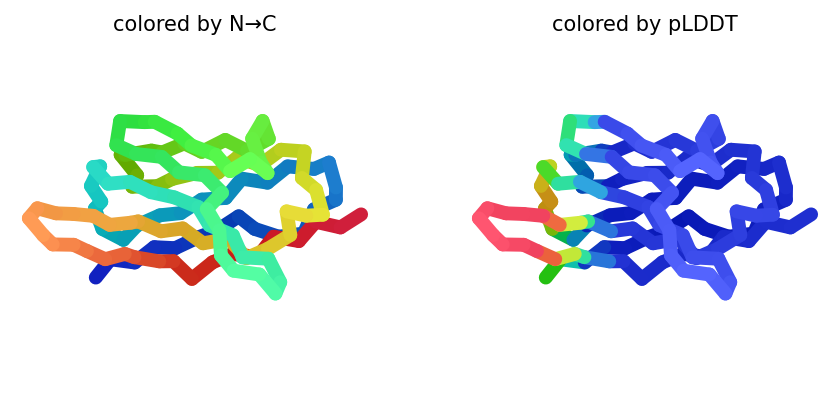

2026-03-06 13:29:05,408 deepfold_v1_model_5_seed_002 recycle=0 pLDDT=87.4
2026-03-06 13:29:13,962 deepfold_v1_model_5_seed_002 recycle=1 pLDDT=87.2 tol=0.394
2026-03-06 13:29:22,530 deepfold_v1_model_5_seed_002 recycle=2 pLDDT=86.8 tol=0.215
2026-03-06 13:29:31,098 deepfold_v1_model_5_seed_002 recycle=3 pLDDT=87.3 tol=0.241
2026-03-06 13:29:39,749 deepfold_v1_model_5_seed_002 recycle=4 pLDDT=86.9 tol=0.262
2026-03-06 13:29:48,537 deepfold_v1_model_5_seed_002 recycle=5 pLDDT=87.9 tol=0.314
2026-03-06 13:29:57,590 deepfold_v1_model_5_seed_002 recycle=6 pLDDT=87.4 tol=0.145
2026-03-06 13:29:57,591 deepfold_v1_model_5_seed_002 took 60.7s (6 recycles)


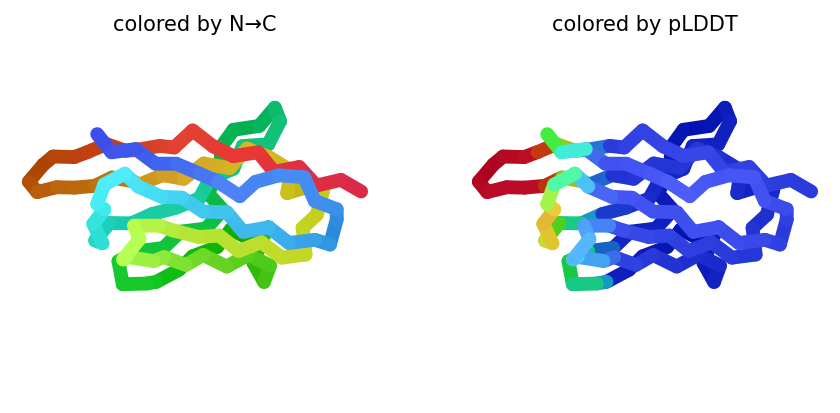

2026-03-06 13:30:13,482 deepfold_v1_model_1_seed_003 recycle=0 pLDDT=88.9
2026-03-06 13:30:22,732 deepfold_v1_model_1_seed_003 recycle=1 pLDDT=87.9 tol=0.419
2026-03-06 13:30:31,982 deepfold_v1_model_1_seed_003 recycle=2 pLDDT=87.9 tol=0.758
2026-03-06 13:30:40,994 deepfold_v1_model_1_seed_003 recycle=3 pLDDT=88.6 tol=0.147
2026-03-06 13:30:49,898 deepfold_v1_model_1_seed_003 recycle=4 pLDDT=88.9 tol=0.0887
2026-03-06 13:30:58,759 deepfold_v1_model_1_seed_003 recycle=5 pLDDT=88.9 tol=0.157
2026-03-06 13:31:07,642 deepfold_v1_model_1_seed_003 recycle=6 pLDDT=89.3 tol=0.294
2026-03-06 13:31:07,643 deepfold_v1_model_1_seed_003 took 63.5s (6 recycles)


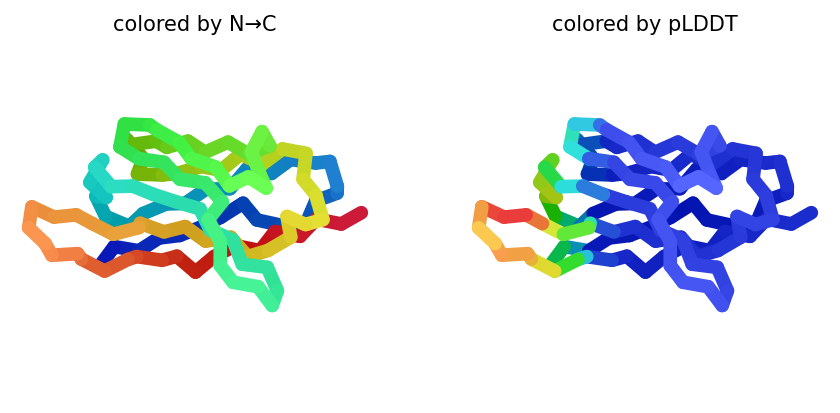

2026-03-06 13:31:16,659 deepfold_v1_model_2_seed_003 recycle=0 pLDDT=87.5
2026-03-06 13:31:25,672 deepfold_v1_model_2_seed_003 recycle=1 pLDDT=86.5 tol=0.345
2026-03-06 13:31:34,744 deepfold_v1_model_2_seed_003 recycle=2 pLDDT=86.5 tol=0.585
2026-03-06 13:31:43,836 deepfold_v1_model_2_seed_003 recycle=3 pLDDT=87.1 tol=0.245
2026-03-06 13:31:52,879 deepfold_v1_model_2_seed_003 recycle=4 pLDDT=87.5 tol=0.0851
2026-03-06 13:32:01,892 deepfold_v1_model_2_seed_003 recycle=5 pLDDT=87.4 tol=0.158
2026-03-06 13:32:10,858 deepfold_v1_model_2_seed_003 recycle=6 pLDDT=87.9 tol=0.22
2026-03-06 13:32:10,859 deepfold_v1_model_2_seed_003 took 63.1s (6 recycles)


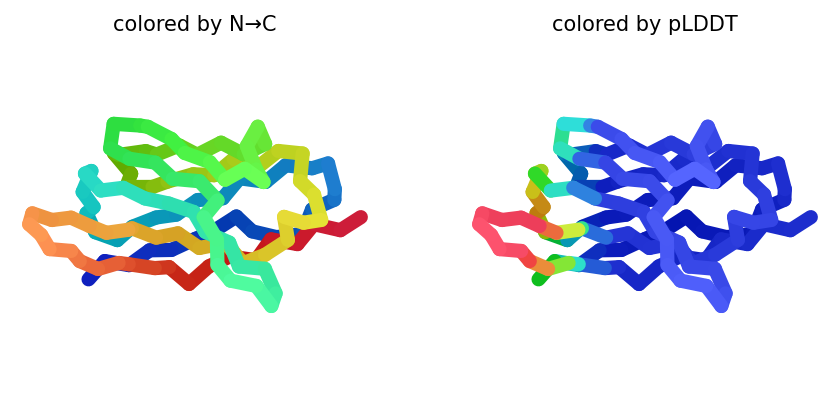

2026-03-06 13:32:19,829 deepfold_v1_model_3_seed_003 recycle=0 pLDDT=88.9
2026-03-06 13:32:28,691 deepfold_v1_model_3_seed_003 recycle=1 pLDDT=87.4 tol=0.551
2026-03-06 13:32:37,578 deepfold_v1_model_3_seed_003 recycle=2 pLDDT=87.2 tol=0.915
2026-03-06 13:32:46,488 deepfold_v1_model_3_seed_003 recycle=3 pLDDT=87.7 tol=1.53
2026-03-06 13:32:55,399 deepfold_v1_model_3_seed_003 recycle=4 pLDDT=88.1 tol=0.157
2026-03-06 13:33:04,328 deepfold_v1_model_3_seed_003 recycle=5 pLDDT=88.1 tol=0.157
2026-03-06 13:33:13,280 deepfold_v1_model_3_seed_003 recycle=6 pLDDT=88.1 tol=0.261
2026-03-06 13:33:13,281 deepfold_v1_model_3_seed_003 took 62.3s (6 recycles)


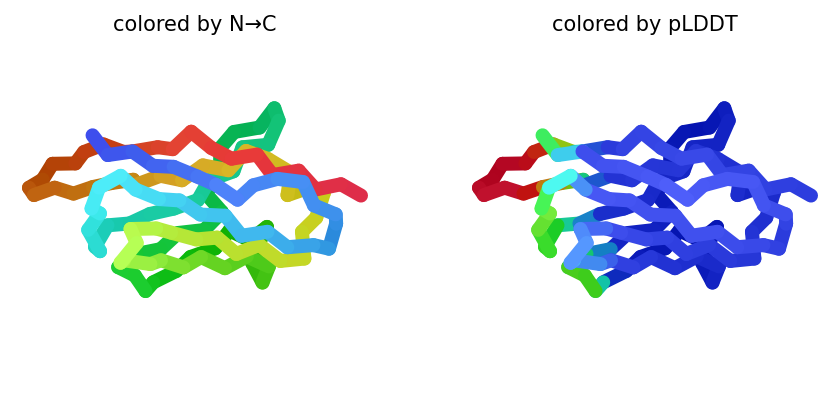

2026-03-06 13:33:22,307 deepfold_v1_model_4_seed_003 recycle=0 pLDDT=87.9
2026-03-06 13:33:31,244 deepfold_v1_model_4_seed_003 recycle=1 pLDDT=86 tol=0.474
2026-03-06 13:33:40,204 deepfold_v1_model_4_seed_003 recycle=2 pLDDT=86.6 tol=1.33
2026-03-06 13:33:49,158 deepfold_v1_model_4_seed_003 recycle=3 pLDDT=86.4 tol=1.69
2026-03-06 13:33:58,098 deepfold_v1_model_4_seed_003 recycle=4 pLDDT=87.2 tol=0.15
2026-03-06 13:34:07,024 deepfold_v1_model_4_seed_003 recycle=5 pLDDT=86.8 tol=0.135
2026-03-06 13:34:15,939 deepfold_v1_model_4_seed_003 recycle=6 pLDDT=87.1 tol=0.272
2026-03-06 13:34:15,940 deepfold_v1_model_4_seed_003 took 62.6s (6 recycles)


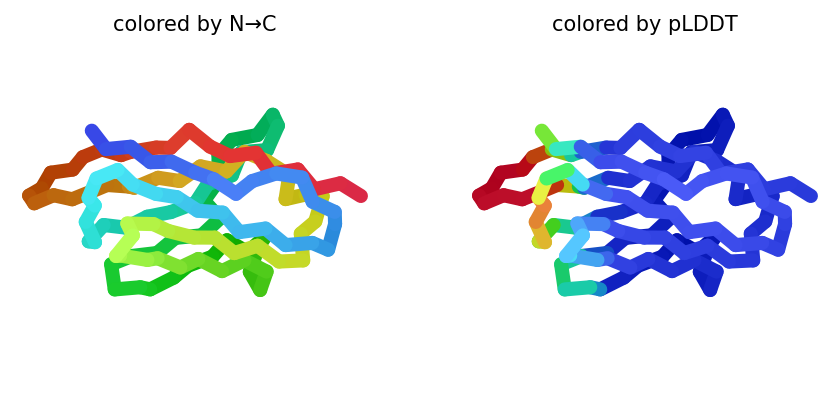

2026-03-06 13:34:24,968 deepfold_v1_model_5_seed_003 recycle=0 pLDDT=87.1
2026-03-06 13:34:33,859 deepfold_v1_model_5_seed_003 recycle=1 pLDDT=86.5 tol=0.327
2026-03-06 13:34:42,737 deepfold_v1_model_5_seed_003 recycle=2 pLDDT=85.5 tol=0.971
2026-03-06 13:34:51,622 deepfold_v1_model_5_seed_003 recycle=3 pLDDT=86.6 tol=0.702
2026-03-06 13:35:00,531 deepfold_v1_model_5_seed_003 recycle=4 pLDDT=87.1 tol=0.466
2026-03-06 13:35:09,450 deepfold_v1_model_5_seed_003 recycle=5 pLDDT=87.2 tol=0.221
2026-03-06 13:35:18,388 deepfold_v1_model_5_seed_003 recycle=6 pLDDT=87.2 tol=0.209
2026-03-06 13:35:18,389 deepfold_v1_model_5_seed_003 took 62.3s (6 recycles)


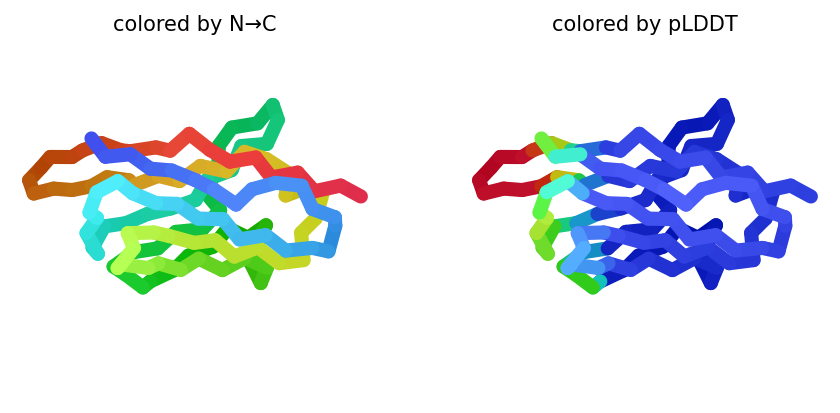

2026-03-06 13:35:18,528 reranking models by 'plddt' metric
2026-03-06 13:35:27,922 Relaxation took 9.4s
2026-03-06 13:35:27,922 rank_001_deepfold_v1_model_1_seed_003 pLDDT=89.3
2026-03-06 13:35:32,305 Relaxation took 4.4s
2026-03-06 13:35:32,305 rank_002_deepfold_v1_model_1_seed_002 pLDDT=89.2
2026-03-06 13:35:37,121 Relaxation took 4.8s
2026-03-06 13:35:37,121 rank_003_deepfold_v1_model_1_seed_000 pLDDT=89.1
2026-03-06 13:35:39,911 Relaxation took 2.8s
2026-03-06 13:35:39,911 rank_004_deepfold_v1_model_1_seed_001 pLDDT=88.9
2026-03-06 13:35:44,341 Relaxation took 4.4s
2026-03-06 13:35:44,342 rank_005_deepfold_v1_model_3_seed_002 pLDDT=88.2
2026-03-06 13:35:44,342 rank_006_deepfold_v1_model_3_seed_003 pLDDT=88.1
2026-03-06 13:35:44,342 rank_007_deepfold_v1_model_2_seed_003 pLDDT=87.9
2026-03-06 13:35:44,342 rank_008_deepfold_v1_model_2_seed_002 pLDDT=87.8
2026-03-06 13:35:44,343 rank_009_deepfold_v1_model_2_seed_000 pLDDT=87.6
2026-03-06 13:35:44,343 rank_010_deepfold_v1_model_3_seed_0

0

In [13]:
#@title Run Prediction
display_images = True #@param {type:"boolean"}

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

download_alphafold_params(model_type, Path("."))
results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=5,
    num_recycles=num_recycles,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1,2,3,4,5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
    calc_extra_ptm=calc_extra_ptm,
)
results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

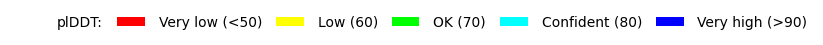

In [14]:
#@title Display 3D structure {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = True #@param {type:"boolean"}
show_mainchains = True #@param {type:"boolean"}

tag = results["rank"][0][rank_num - 1]
jobname_prefix = ".custom" if msa_mode == "custom" else ""
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
if color == "lDDT":
  plot_plddt_legend().show()


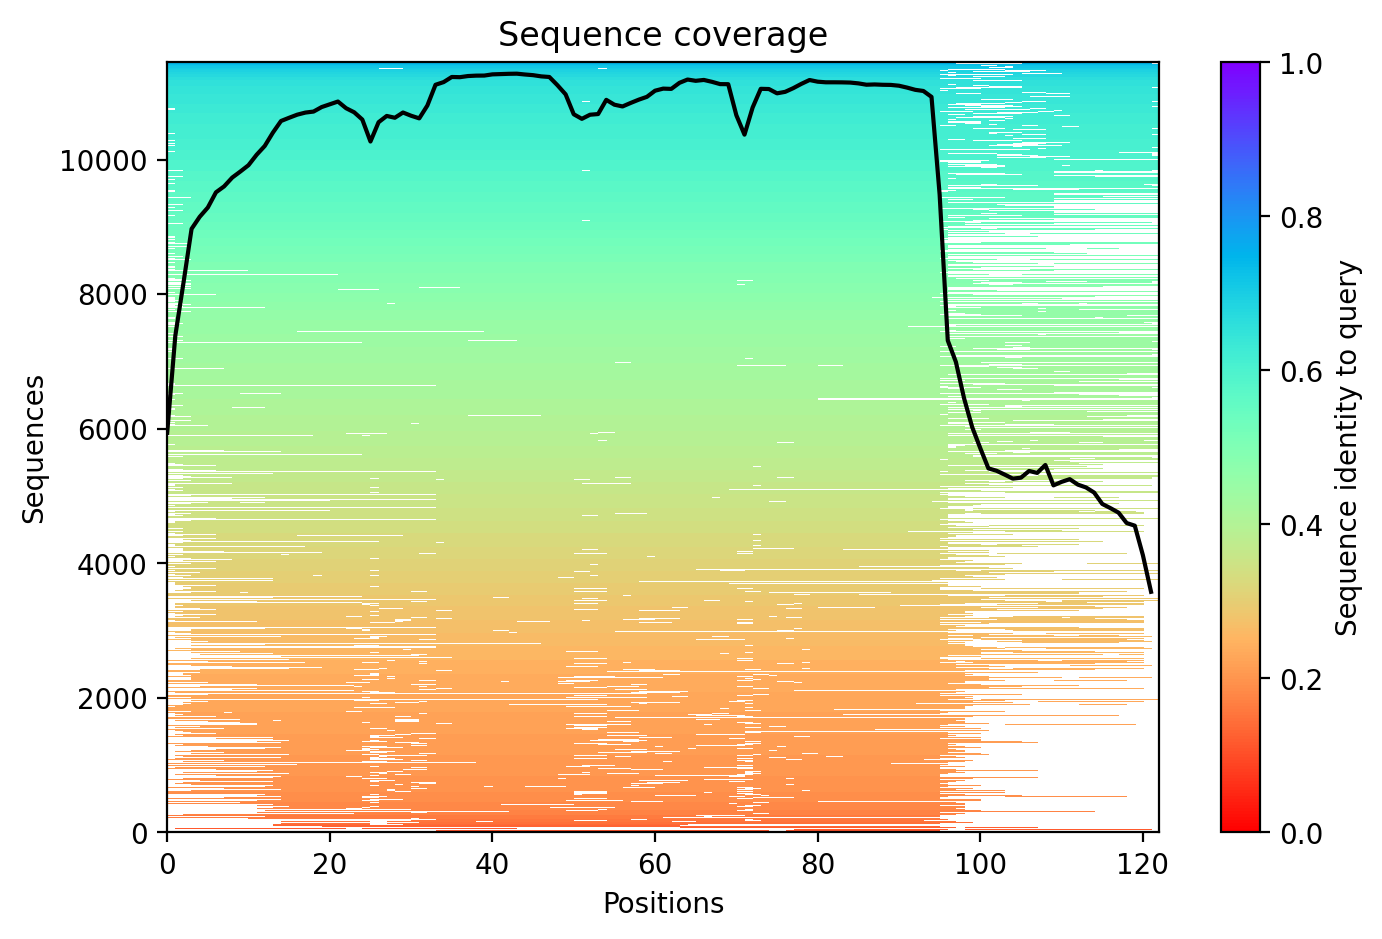
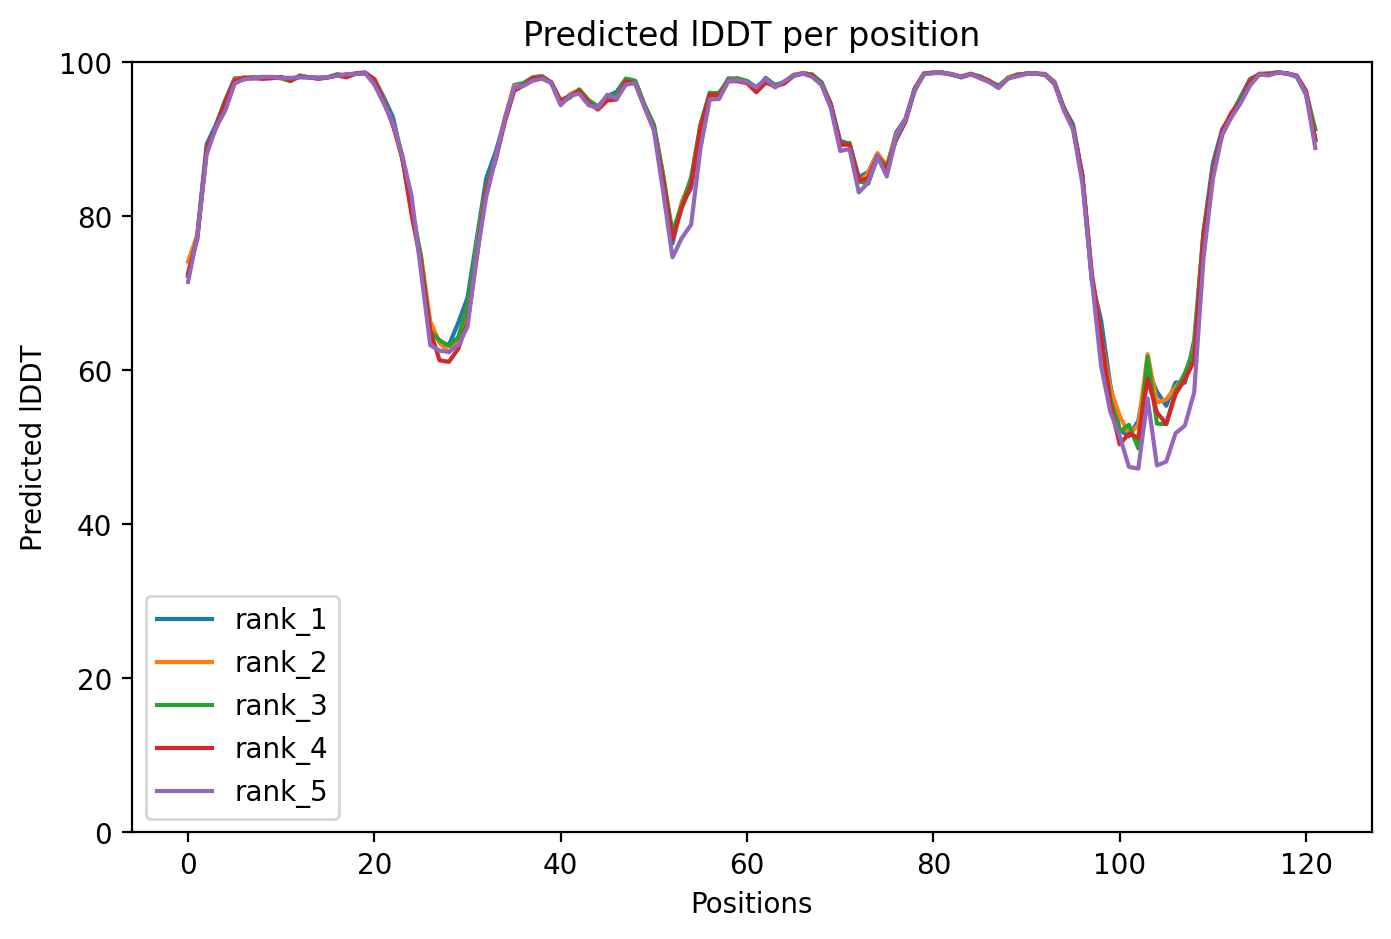

In [15]:
#@title Plots {run: "auto"}
from IPython.display import display, HTML
import base64
from html import escape

# see: https://stackoverflow.com/a/53688522
def image_to_data_url(filename):
  ext = filename.split('.')[-1]
  prefix = f'data:image/{ext};base64,'
  with open(filename, 'rb') as f:
    img = f.read()
  return prefix + base64.b64encode(img).decode('utf-8')

pae = ""
pae_file = os.path.join(jobname,f"{jobname}{jobname_prefix}_pae.png")
if os.path.isfile(pae_file):
    pae = image_to_data_url(pae_file)
cov = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_coverage.png"))
plddt = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_plddt.png"))
display(HTML(f"""
<style>
  img {{
    float:left;
  }}
  .full {{
    max-width:100%;
  }}
  .half {{
    max-width:50%;
  }}
  @media (max-width:640px) {{
    .half {{
      max-width:100%;
    }}
  }}
</style>
<div style="max-width:90%; padding:2em;">
  <h1>Plots for {escape(jobname)}</h1>
  { '<!--' if pae == '' else '' }<img src="{pae}" class="full" />{ '-->' if pae == '' else '' }
  <img src="{cov}" class="half" />
  <img src="{plddt}" class="half" />
</div>
"""))

In [16]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive, try disabling your adblocker and run this cell again. If that fails click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

if msa_mode == "custom":
  print("Don't forget to cite your custom MSA generation method.")

files.download(f"{jobname}.result.zip")

if save_to_google_drive == True and drive:
  uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
  uploaded.SetContentFile(f"{jobname}.result.zip")
  uploaded.Upload()
  print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Instructions <a name="Instructions"></a>
For detailed instructions, tips and tricks, see recently published paper at [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5)

**Quick start**
1. Paste your protein sequence(s) in the input field.
2. Press "Runtime" -> "Run all".
3. The pipeline consists of 5 steps. The currently running step is indicated by a circle with a stop sign next to it.

**Result zip file contents**

1. PDB formatted structures sorted by avg. pLDDT and complexes are sorted by pTMscore. (unrelaxed and relaxed if `use_amber` is enabled).
2. Plots of the model quality.
3. Plots of the MSA coverage.
4. Parameter log file.
5. A3M formatted input MSA.
6. A `predicted_aligned_error_v1.json` using [AlphaFold-DB's format](https://alphafold.ebi.ac.uk/faq#faq-7) and a `scores.json` for each model which contains an array (list of lists) for PAE, a list with the average pLDDT and the pTMscore.
7. BibTeX file with citations for all used tools and databases.

At the end of the job a download modal box will pop up with a `jobname.result.zip` file. Additionally, if the `save_to_google_drive` option was selected, the `jobname.result.zip` will be uploaded to your Google Drive.

**MSA generation for complexes**

For the complex prediction we use unpaired and paired MSAs. Unpaired MSA is generated the same way as for the protein structures prediction by searching the UniRef100 and environmental sequences three iterations each.

The paired MSA is generated by searching the UniRef100 database and pairing the best hits sharing the same NCBI taxonomic identifier (=species or sub-species). We only pair sequences if all of the query sequences are present for the respective taxonomic identifier.

**Using a custom MSA as input**

To predict the structure with a custom MSA (A3M formatted): (1) Change the `msa_mode`: to "custom", (2) Wait for an upload box to appear at the end of the "MSA options ..." box. Upload your A3M. The first fasta entry of the A3M must be the query sequence without gaps.

It is also possilbe to provide custom MSAs for complex predictions. Read more about the format [here](https://github.com/sokrypton/ColabFold/issues/76).

As an alternative for MSA generation the [HHblits Toolkit server](https://toolkit.tuebingen.mpg.de/tools/hhblits) can be used. After submitting your query, click "Query Template MSA" -> "Download Full A3M". Download the A3M file and upload it in this notebook.

**PDB100** <a name="pdb100"></a>

As of 23/06/08, we have transitioned from using the PDB70 to a 100% clustered PDB, the PDB100. The construction methodology of PDB100 differs from that of PDB70.

The PDB70 was constructed by running each PDB70 representative sequence through [HHblits](https://github.com/soedinglab/hh-suite) against the [Uniclust30](https://uniclust.mmseqs.com/). On the other hand, the PDB100 is built by searching each PDB100 representative structure with [Foldseek](https://github.com/steineggerlab/foldseek) against the [AlphaFold Database](https://alphafold.ebi.ac.uk).

To maintain compatibility with older Notebook versions and local installations, the generated files and API responses will continue to be named "PDB70", even though we're now using the PDB100.

**Using custom templates** <a name="custom_templates"></a>

To predict the structure with a custom template (PDB or mmCIF formatted): (1) change the `template_mode` to "custom" in the execute cell and (2) wait for an upload box to appear at the end of the "Input Protein" box. Select and upload your templates (multiple choices are possible).

* Templates must follow the four letter PDB naming with lower case letters.

* Templates in mmCIF format must contain `_entity_poly_seq`. An error is thrown if this field is not present. The field `_pdbx_audit_revision_history.revision_date` is automatically generated if it is not present.

* Templates in PDB format are automatically converted to the mmCIF format. `_entity_poly_seq` and `_pdbx_audit_revision_history.revision_date` are automatically generated.

If you encounter problems, please report them to this [issue](https://github.com/sokrypton/ColabFold/issues/177).

**Comparison to the full AlphaFold2 and AlphaFold2 Colab**

This notebook replaces the homology detection and MSA pairing of AlphaFold2 with MMseqs2. For a comparison against the [AlphaFold2 Colab](https://colab.research.google.com/github/deepmind/alphafold/blob/main/notebooks/AlphaFold.ipynb) and the full [AlphaFold2](https://github.com/deepmind/alphafold) system read our [paper](https://www.nature.com/articles/s41592-022-01488-1).

**Troubleshooting**
* Check that the runtime type is set to GPU at "Runtime" -> "Change runtime type".
* Try to restart the session "Runtime" -> "Factory reset runtime".
* Check your input sequence.

**Known issues**
* Google Colab assigns different types of GPUs with varying amount of memory. Some might not have enough memory to predict the structure for a long sequence.
* Your browser can block the pop-up for downloading the result file. You can choose the `save_to_google_drive` option to upload to Google Drive instead or manually download the result file: Click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

**Limitations**
* Computing resources: Our MMseqs2 API can handle ~20-50k requests per day.
* MSAs: MMseqs2 is very precise and sensitive but might find less hits compared to HHblits/HMMer searched against BFD or MGnify.
* We recommend to additionally use the full [AlphaFold2 pipeline](https://github.com/deepmind/alphafold).

**Description of the plots**
*   **Number of sequences per position** - We want to see at least 30 sequences per position, for best performance, ideally 100 sequences.
*   **Predicted lDDT per position** - model confidence (out of 100) at each position. The higher the better.
*   **Predicted Alignment Error** - For homooligomers, this could be a useful metric to assess how confident the model is about the interface. The lower the better.

**Bugs**
- If you encounter any bugs, please report the issue to https://github.com/sokrypton/ColabFold/issues

**License**

The source code of ColabFold is licensed under [MIT](https://raw.githubusercontent.com/sokrypton/ColabFold/main/LICENSE). Additionally, this notebook uses the AlphaFold2 source code and its parameters licensed under [Apache 2.0](https://raw.githubusercontent.com/deepmind/alphafold/main/LICENSE) and [CC BY 4.0](https://creativecommons.org/licenses/by-sa/4.0/) respectively. Read more about the AlphaFold license [here](https://github.com/deepmind/alphafold).

**Acknowledgments**
- We thank the AlphaFold team for developing an excellent model and open sourcing the software.

- [KOBIC](https://kobic.re.kr) and [Söding Lab](https://www.mpinat.mpg.de/soeding) for providing the computational resources for the MMseqs2 MSA server.

- Richard Evans for helping to benchmark the ColabFold's Alphafold-multimer support.

- [David Koes](https://github.com/dkoes) for his awesome [py3Dmol](https://3dmol.csb.pitt.edu/) plugin, without whom these notebooks would be quite boring!

- Do-Yoon Kim for creating the ColabFold logo.

- A colab by Sergey Ovchinnikov ([@sokrypton](https://twitter.com/sokrypton)), Milot Mirdita ([@milot_mirdita](https://twitter.com/milot_mirdita)) and Martin Steinegger ([@thesteinegger](https://twitter.com/thesteinegger)).
